In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad
import trimesh

In [36]:
df = pd.read_pickle('./data.pkl')

In [37]:
# TPC boundaries (cm)
tpcMinX = -200
tpcMaxX = 200
tpcMinY = -200
tpcMaxY = 200
tpcMinZ = 0
tpcMaxZ = 500

# Beam center (cm)
beamCenterX = -74
beamCenterY = 0
beamCenterZ = 11000

In [52]:
# Plot settings
colorTot = 'C3'; colorP = 'C0'; colorNP = 'C1'
ylimit = (0,)
xlimit=(0,)
erAlpha = 0.3

nbins = np.arange(0, 4.1, .2)
nbinsTPC = np.arange(0, 1.61, .2)
distBins = np.arange(0, 201, 4)
zBins = np.arange(0, 501, 20)

In [39]:
# Front face normalization
norm_areas = np.array([])
r1 = 1.26  # m
r2 = 2.0   # m
r3 = 2.74  # m
for i in range(len(nbinsTPC)-1):
    radius = (beamCenterZ/100) * np.tan(nbinsTPC[i+1] * np.pi / 180)
    area = np.pi * radius**2
    if i > 0:
        if radius > r1:
            area -= quad(lambda x: 2*np.sqrt(radius**2 - x**2), 1.26, radius)[0]
        if radius > r2:
            area -= quad(lambda y: 4*np.sqrt(radius**2 - y**2), 2, radius)[0]
        if radius > np.sqrt(r1**2 + r2**2):
            area += quad(lambda x1: 2*(np.sqrt(radius**2 - x1**2) - 2), 1.26, np.sqrt(radius**2 - 4))[0]
        if radius > r3:
            area -= quad(lambda z: 2*np.sqrt(radius**2 - z**2), 2.74, radius)[0]
        if radius > np.sqrt(r3**2 + r2**2):
            area += quad(lambda x2: 2*(np.sqrt(radius**2 - x2**2) - 2), 2.74, np.sqrt(radius**2 - 4))[0]
        area -= np.sum(norm_areas[0:i])
    if area < 1e-5:
        area = 0
    norm_areas = np.append(norm_areas, np.abs(area))
norm_areas

array([0.46318395, 1.38959699, 2.31614549, 2.91337013, 3.17304591,
       2.64577569, 1.79511938, 1.07684058])

In [40]:
# Back face normalization
norm_areas_back = np.array([])
for i in range(len(nbinsTPC)-1):
    radius = ((beamCenterZ+tpcMaxZ-tpcMinZ)/100) * np.tan(nbinsTPC[i+1] * np.pi / 180)
    area = np.pi * radius**2
    if i > 0:
        if radius > r1:
            area -= quad(lambda x: 2*np.sqrt(radius**2 - x**2), 1.26, radius)[0]
        if radius > r2:
            area -= quad(lambda y: 4*np.sqrt(radius**2 - y**2), 2, radius)[0]
        if radius > np.sqrt(r1**2 + r2**2):
            area += quad(lambda x1: 2*(np.sqrt(radius**2 - x1**2) - 2), 1.26, np.sqrt(radius**2 - 4))[0]
        if radius > r3:
            area -= quad(lambda z: 2*np.sqrt(radius**2 - z**2), 2.74, radius)[0]
        if radius > np.sqrt(r3**2 + r2**2):
            area += quad(lambda x2: 2*(np.sqrt(radius**2 - x2**2) - 2), 2.74, np.sqrt(radius**2 - 4))[0]
        area -= np.sum(norm_areas[0:i])
    if area < 1e-5:
        area = 0
    norm_areas_back = np.append(norm_areas_back, np.abs(area))
norm_areas_back

array([0.50624857, 1.56185968, 2.70375229, 3.46214343, 3.94690699,
       3.15426951, 2.28352461, 1.23375337])

In [41]:
# exact volume normalization
tpcBox = trimesh.creation.box(extents=[4, 4, 5])
tpcBox.apply_translation([-.74, 0, 2.5])
norm_vols = np.array([])
for i in range(len(nbinsTPC)-1):
    radius = 115 * np.tan(nbinsTPC[i+1] * np.pi / 180)
    cone = trimesh.creation.cone(radius=radius, height=115)
    vol = cone.volume - cone.difference(tpcBox).volume
    if i > 0:
        vol -= np.sum(norm_vols[0:i])
    if vol < 1e-5:
        vol = 0
    norm_vols = np.append(norm_vols, vol)
norm_vols

array([ 2.40724613,  7.22197472, 12.03740189, 14.91265475, 16.34991851,
       12.68422353,  8.99719651,  4.62961908])

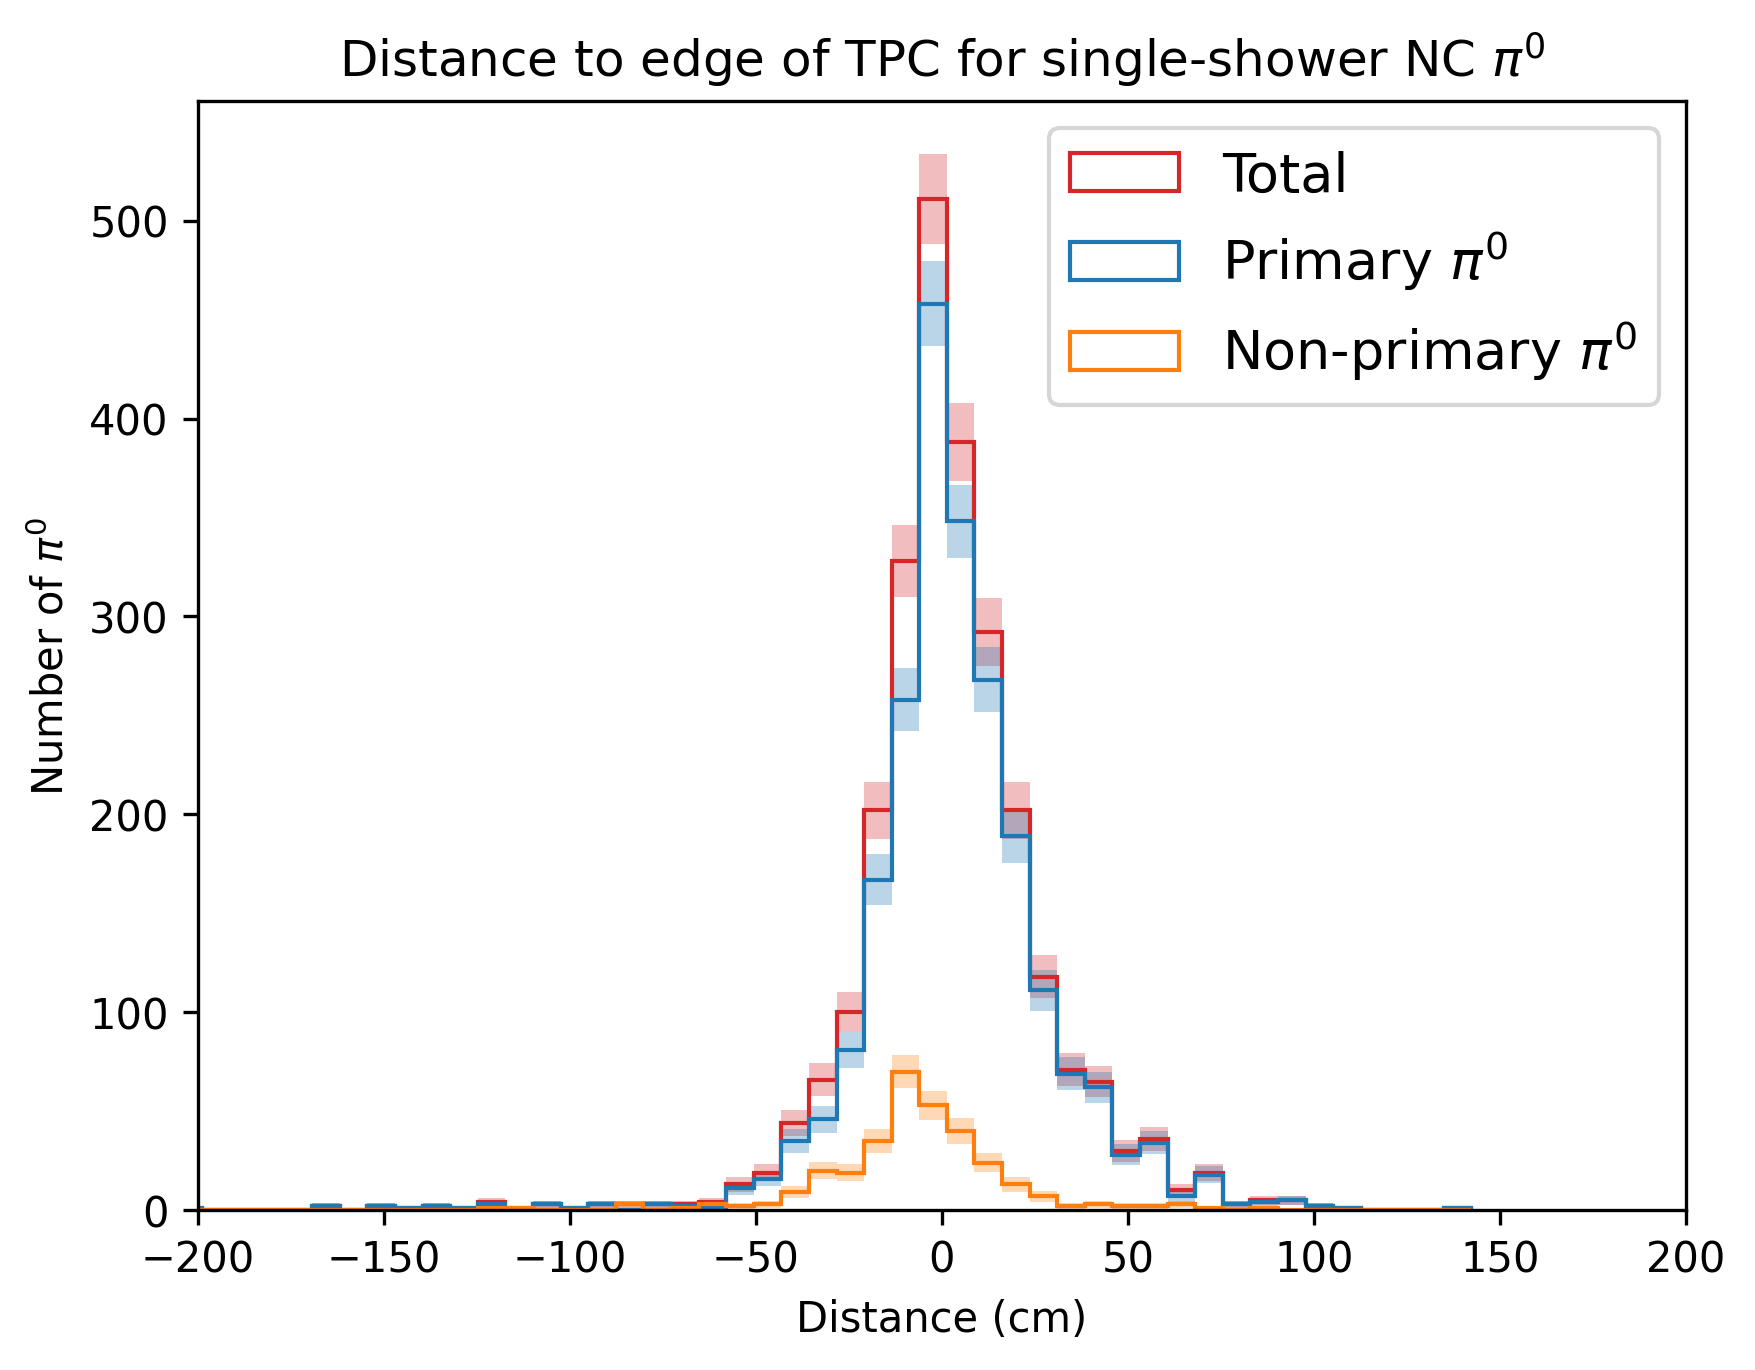

In [48]:
distancesNPSig = np.array([])
distancesPSig = np.array([])
distancesSig = np.array([])
for idx, row in df[df['is_NC'] & df['single_shower']].iterrows():
    for k in range(len(row['shower_pi0_dex'])):
        distancesSig = np.append(distancesSig, row['signed_dist_to_edge_g4'][row['shower_pi0_dex'][k]])
        if row['shower_pi0_dex'][k] == 0:
            distancesPSig = np.append(distancesPSig, row['signed_dist_to_edge_g4'][row['shower_pi0_dex'][k]])
        else:
            distancesNPSig = np.append(distancesNPSig, row['signed_dist_to_edge_g4'][row['shower_pi0_dex'][k]])
assert len(distancesPSig)+len(distancesNPSig) == len(distancesSig)

plt.figure(dpi=300)
counts, bins, _ = plt.hist(distancesSig, bins=100, histtype='step')
cP, bP, _ = plt.hist(distancesPSig, bins=bins, histtype='step')
cNP, bNP, _ = plt.hist(distancesNPSig, bins=bins, histtype='step')
wide = np.diff(bins)
plt.clf()  # clear the previous plot
bin_centers = 0.5 * (bins[:-1] + bins[1:])
errors = np.sqrt(counts)
errP = np.sqrt(cP)
errNP = np.sqrt(cNP)
plt.bar(bin_centers, 2*errors, width=wide, bottom=counts-errors, color=colorTot, alpha=erAlpha, align='center', edgecolor='none')
plt.hist(bins[:-1], bins=bins, weights=counts, histtype='step', color=colorTot, label='Total')
plt.bar(bin_centers, 2*errP, width=wide, bottom=cP-errP, color=colorP, alpha=erAlpha, align='center', edgecolor='none')
plt.hist(bins[:-1], bins=bins, weights=cP, histtype='step', color=colorP, label='Primary $\pi^0$')
plt.bar(bin_centers, 2*errNP, width=wide, bottom=cNP-errNP, color=colorNP, alpha=erAlpha, align='center', edgecolor='none')
plt.hist(bins[:-1], bins=bins, weights=cNP, histtype='step', color=colorNP, label='Non-primary $\pi^0$')
plt.title(r'Distance to edge of TPC for single-shower NC $\pi^0$')
plt.xlabel('Distance (cm)')
plt.ylabel(r'Number of $\pi^0$')
plt.xlim(-200, 200)
plt.ylim(*ylimit)
plt.legend(prop={'size': 13})
plt.show()

## Set B: Single shower (shower head)

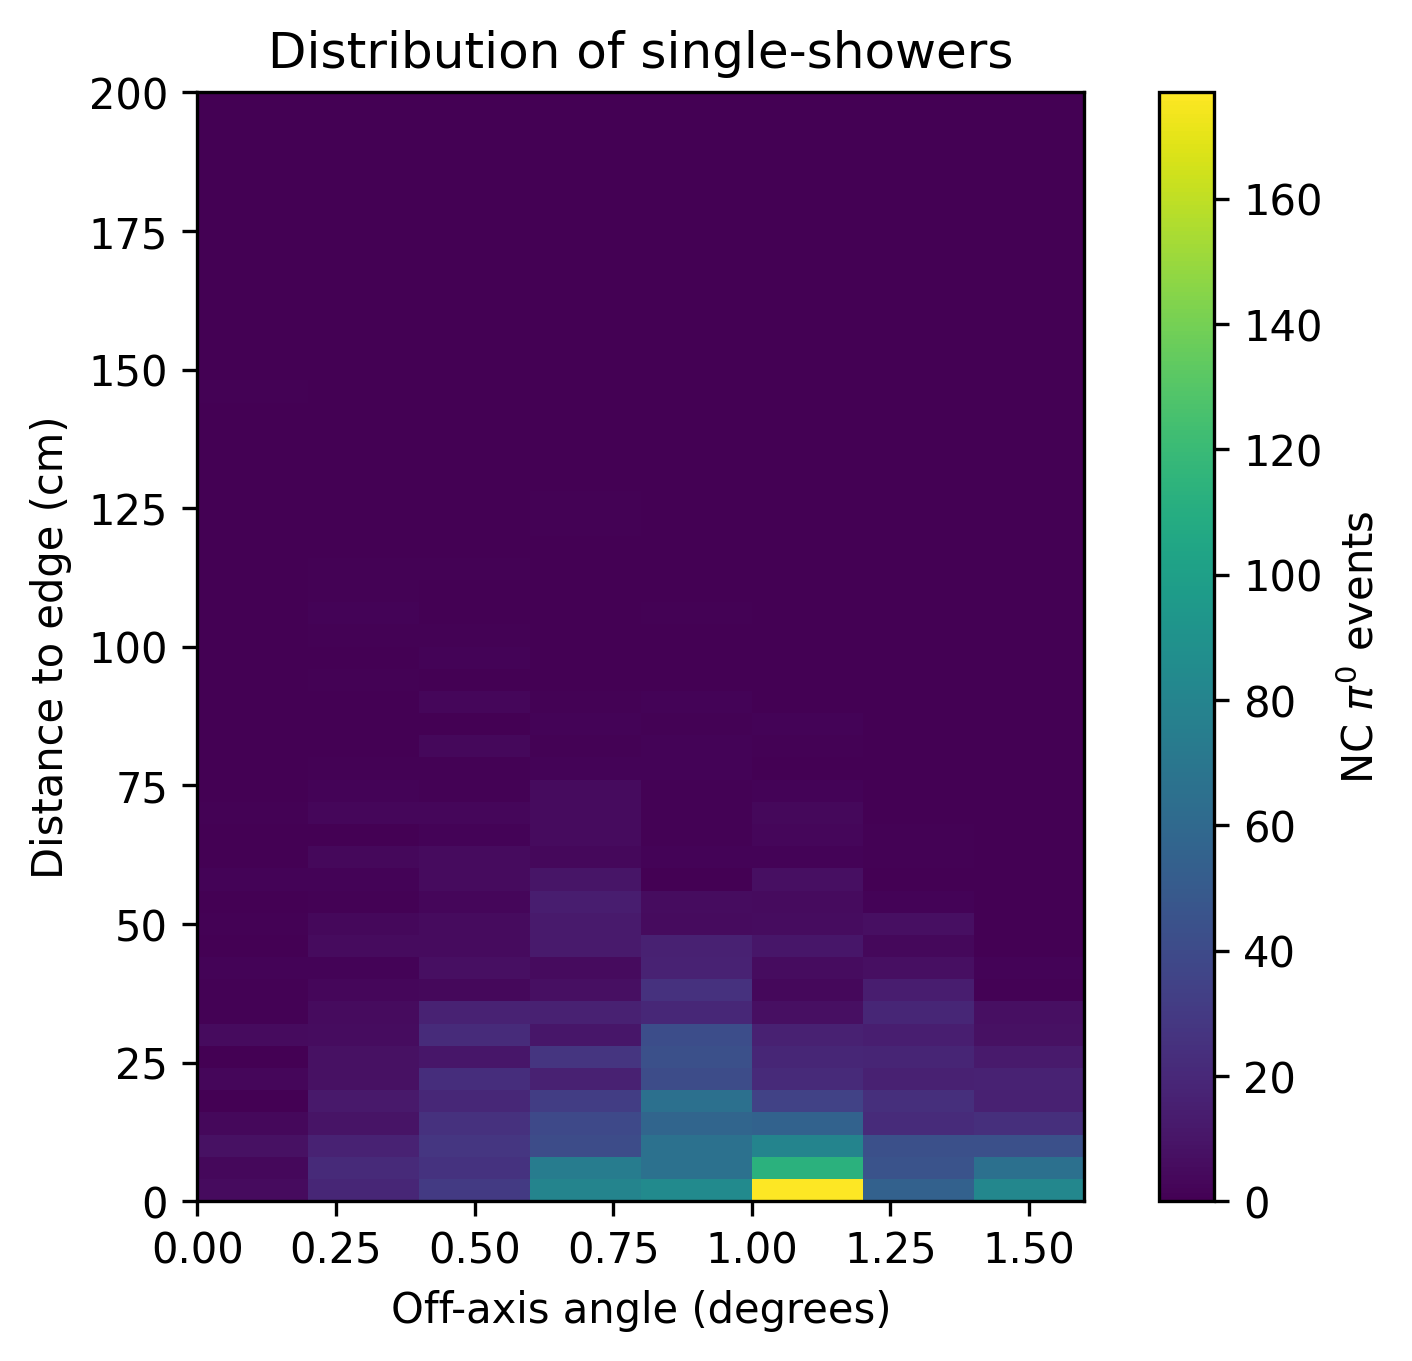

In [43]:
distAngHeatmap = np.zeros((len(distBins[:-1]), len(nbinsTPC[:-1])))
for idx, row in df[df['is_NC'] & df['single_shower']].iterrows():
    for k in range(len(row['shower_dist_to_edge'])):
        angDex = np.digitize(row['shower_angle_exact'][k], nbinsTPC[:-1]) - 1
        distDex = np.digitize(row['shower_dist_to_edge'][k], distBins[:-1]) - 1
        distAngHeatmap[distDex, angDex] += 1

plt.figure(dpi=300)
plt.imshow(distAngHeatmap, cmap='viridis', extent=[nbinsTPC[0], nbinsTPC[-1], distBins[-1], distBins[0]], aspect=.01)
plt.xlabel("Off-axis angle (degrees)")
plt.ylabel("Distance to edge (cm)")
plt.colorbar(label="NC $\pi^0$ events")
plt.gca().invert_yaxis()
plt.title("Distribution of single-showers")
plt.show()

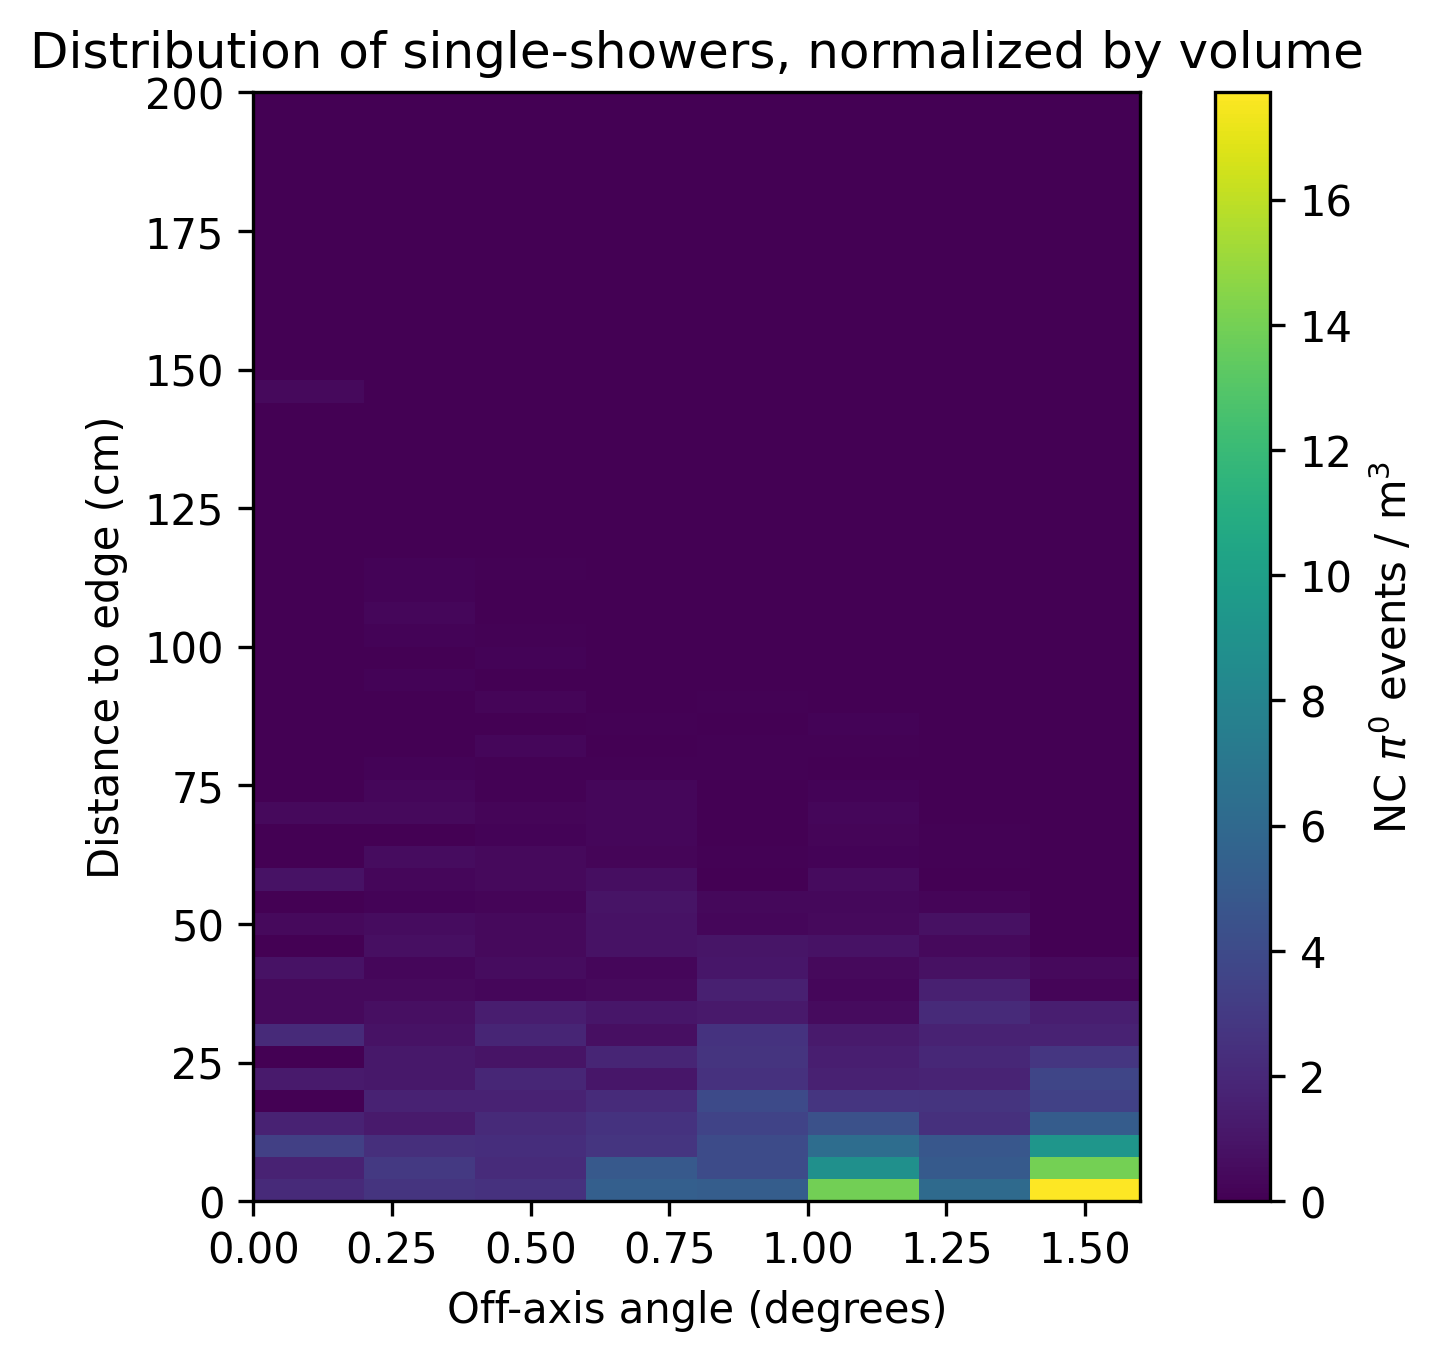

In [56]:
distAngHeatmap = np.zeros((len(distBins[:-1]), len(nbinsTPC[:-1])))
for idx, row in df[df['is_NC'] & df['single_shower']].iterrows():
    for k in range(len(row['shower_dist_to_edge'])):
        angDex = np.digitize(row['shower_angle_exact'][k], nbinsTPC[:-1]) - 1
        distDex = np.digitize(row['shower_dist_to_edge'][k], distBins[:-1]) - 1
        distAngHeatmap[distDex, angDex] += 1/norm_vols[angDex]

plt.figure(dpi=300)
plt.imshow(distAngHeatmap, cmap='viridis', extent=[nbinsTPC[0], nbinsTPC[-1], distBins[-1], distBins[0]], aspect=.01)
plt.xlabel("Off-axis angle (degrees)")
plt.ylabel("Distance to edge (cm)")
plt.colorbar(label="NC $\pi^0$ events / m$^3$")
plt.gca().invert_yaxis()
plt.title("Distribution of single-showers, normalized by volume")
plt.show()

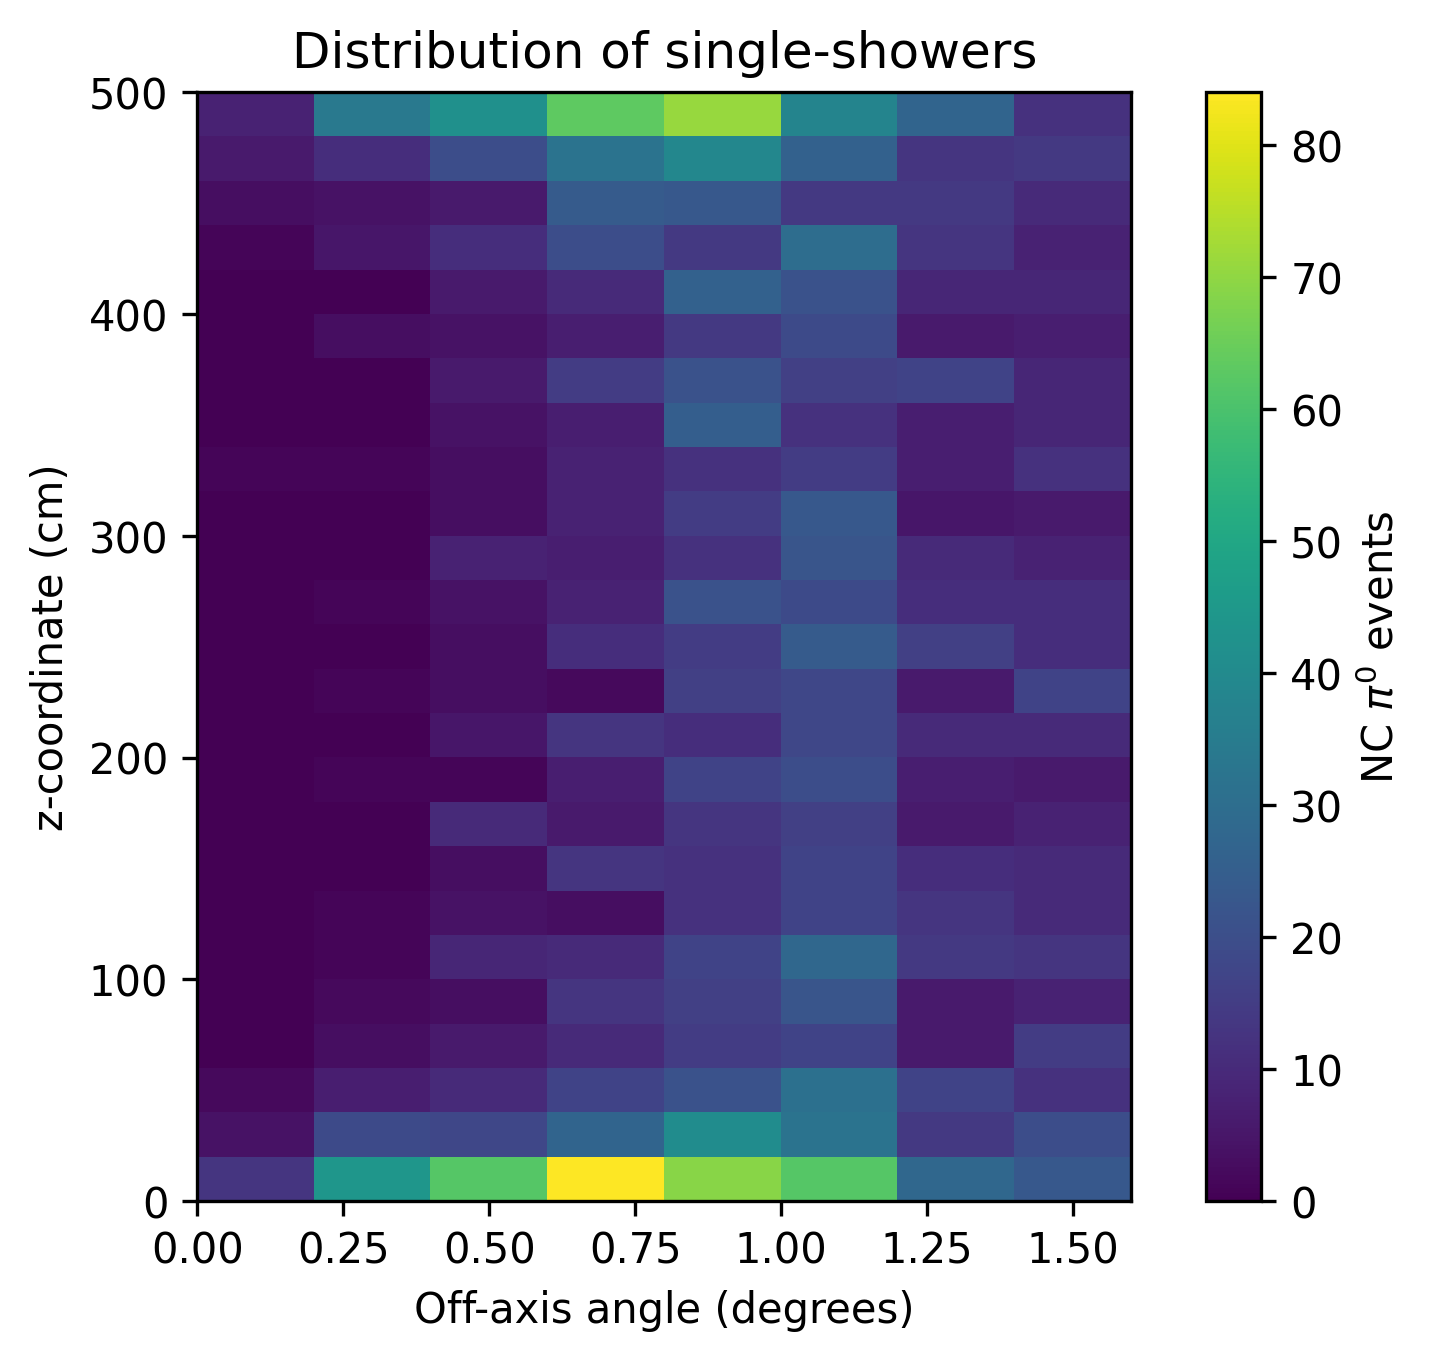

In [53]:
zAngHeatmap = np.zeros((len(zBins[:-1]), len(nbinsTPC[:-1])))
for idx, row in df[df['is_NC'] & df['single_shower']].iterrows():
    for k in range(len(row['shower_angle_exact'])):
        angDex = np.digitize(row['shower_angle_exact'][k], nbinsTPC[:-1]) - 1
        zDex = np.digitize(row['shower_position'][k][2], zBins[:-1]) - 1
        zAngHeatmap[zDex, angDex] += 1

plt.figure(dpi=300)
plt.imshow(zAngHeatmap, cmap='viridis', extent=[nbinsTPC[0], nbinsTPC[-1], zBins[-1], zBins[0]], aspect=.0038)
plt.xlabel("Off-axis angle (degrees)")
plt.ylabel("z-coordinate (cm)")
plt.colorbar(label="NC $\pi^0$ events")
plt.gca().invert_yaxis()
plt.title("Distribution of single-showers")
plt.show()

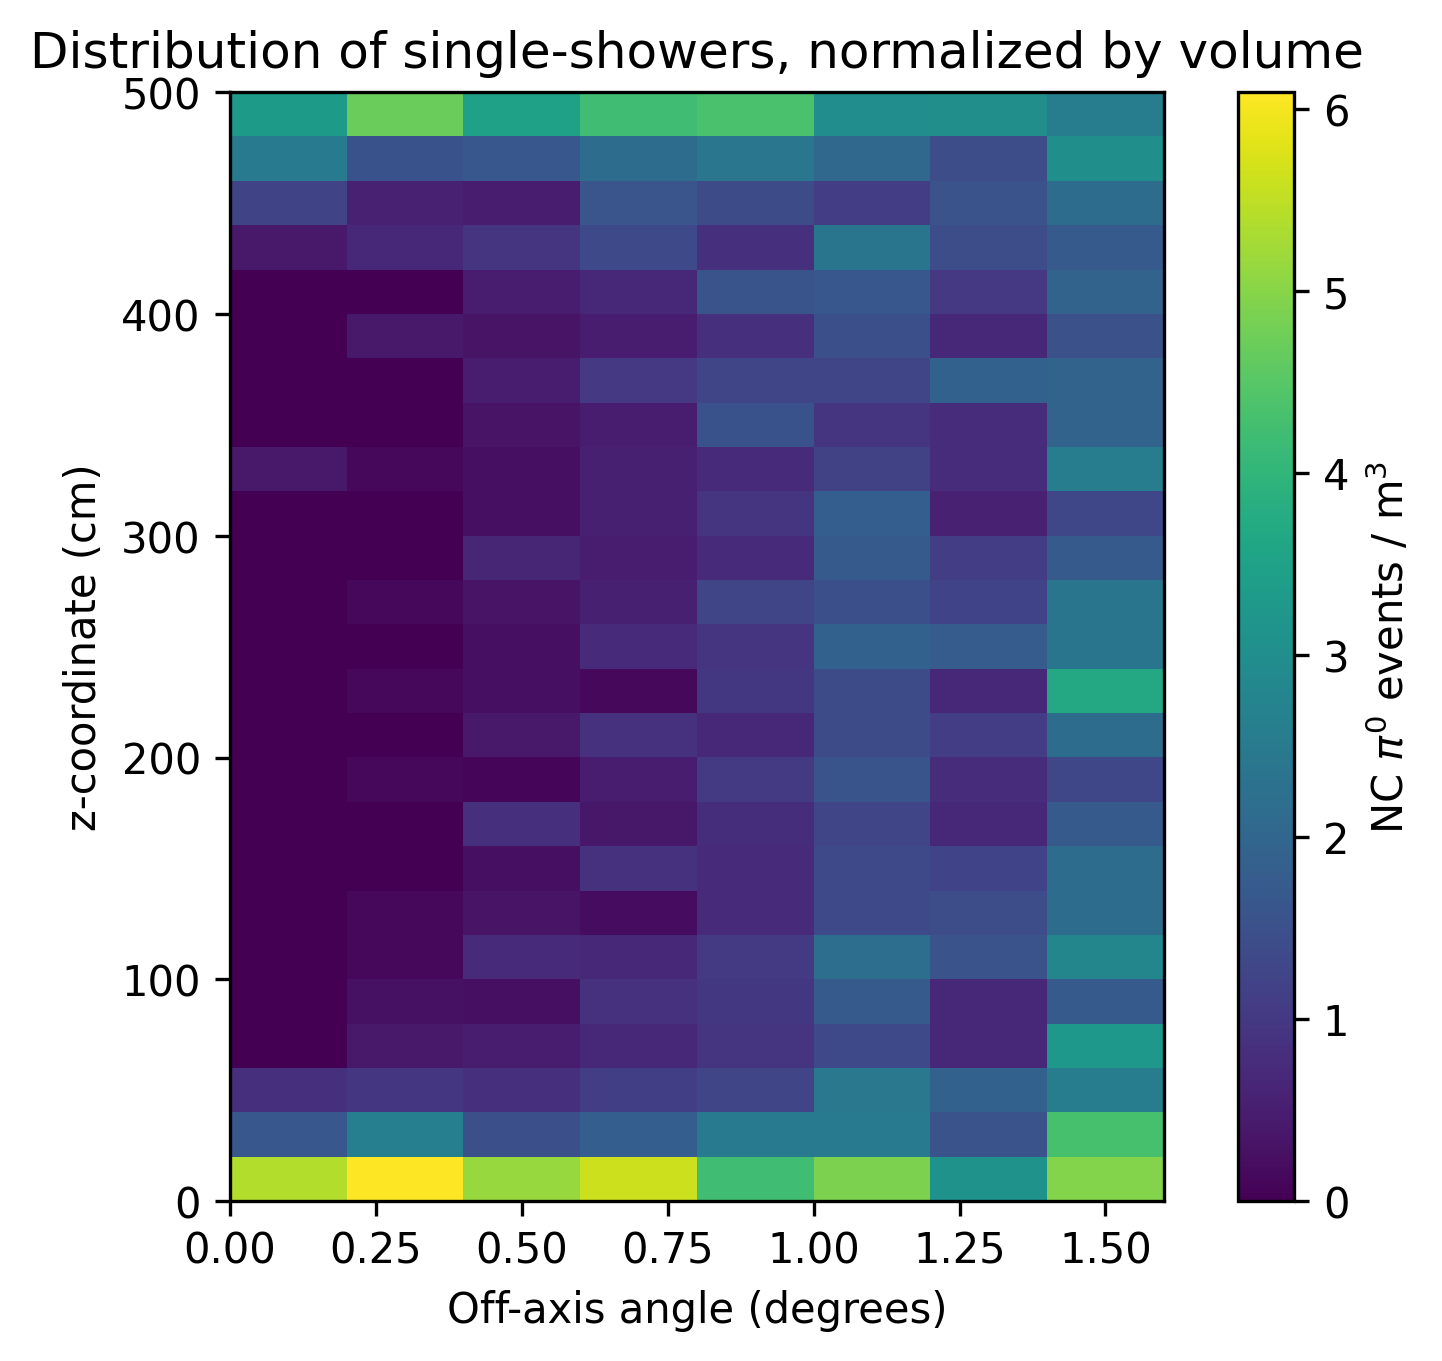

In [57]:
zAngHeatmap = np.zeros((len(zBins[:-1]), len(nbinsTPC[:-1])))
for idx, row in df[df['is_NC'] & df['single_shower']].iterrows():
    for k in range(len(row['shower_angle_exact'])):
        angDex = np.digitize(row['shower_angle_exact'][k], nbinsTPC[:-1]) - 1
        zDex = np.digitize(row['shower_position'][k][2], zBins[:-1]) - 1
        zAngHeatmap[zDex, angDex] += 1/norm_vols[angDex]

plt.figure(dpi=300)
plt.imshow(zAngHeatmap, cmap='viridis', extent=[nbinsTPC[0], nbinsTPC[-1], zBins[-1], zBins[0]], aspect=.0038)
plt.xlabel("Off-axis angle (degrees)")
plt.ylabel("z-coordinate (cm)")
plt.colorbar(label="NC $\pi^0$ events / m$^3$")
plt.gca().invert_yaxis()
plt.title("Distribution of single-showers, normalized by volume")
plt.show()

## Set C: Single shower with proton (interaction vertex)

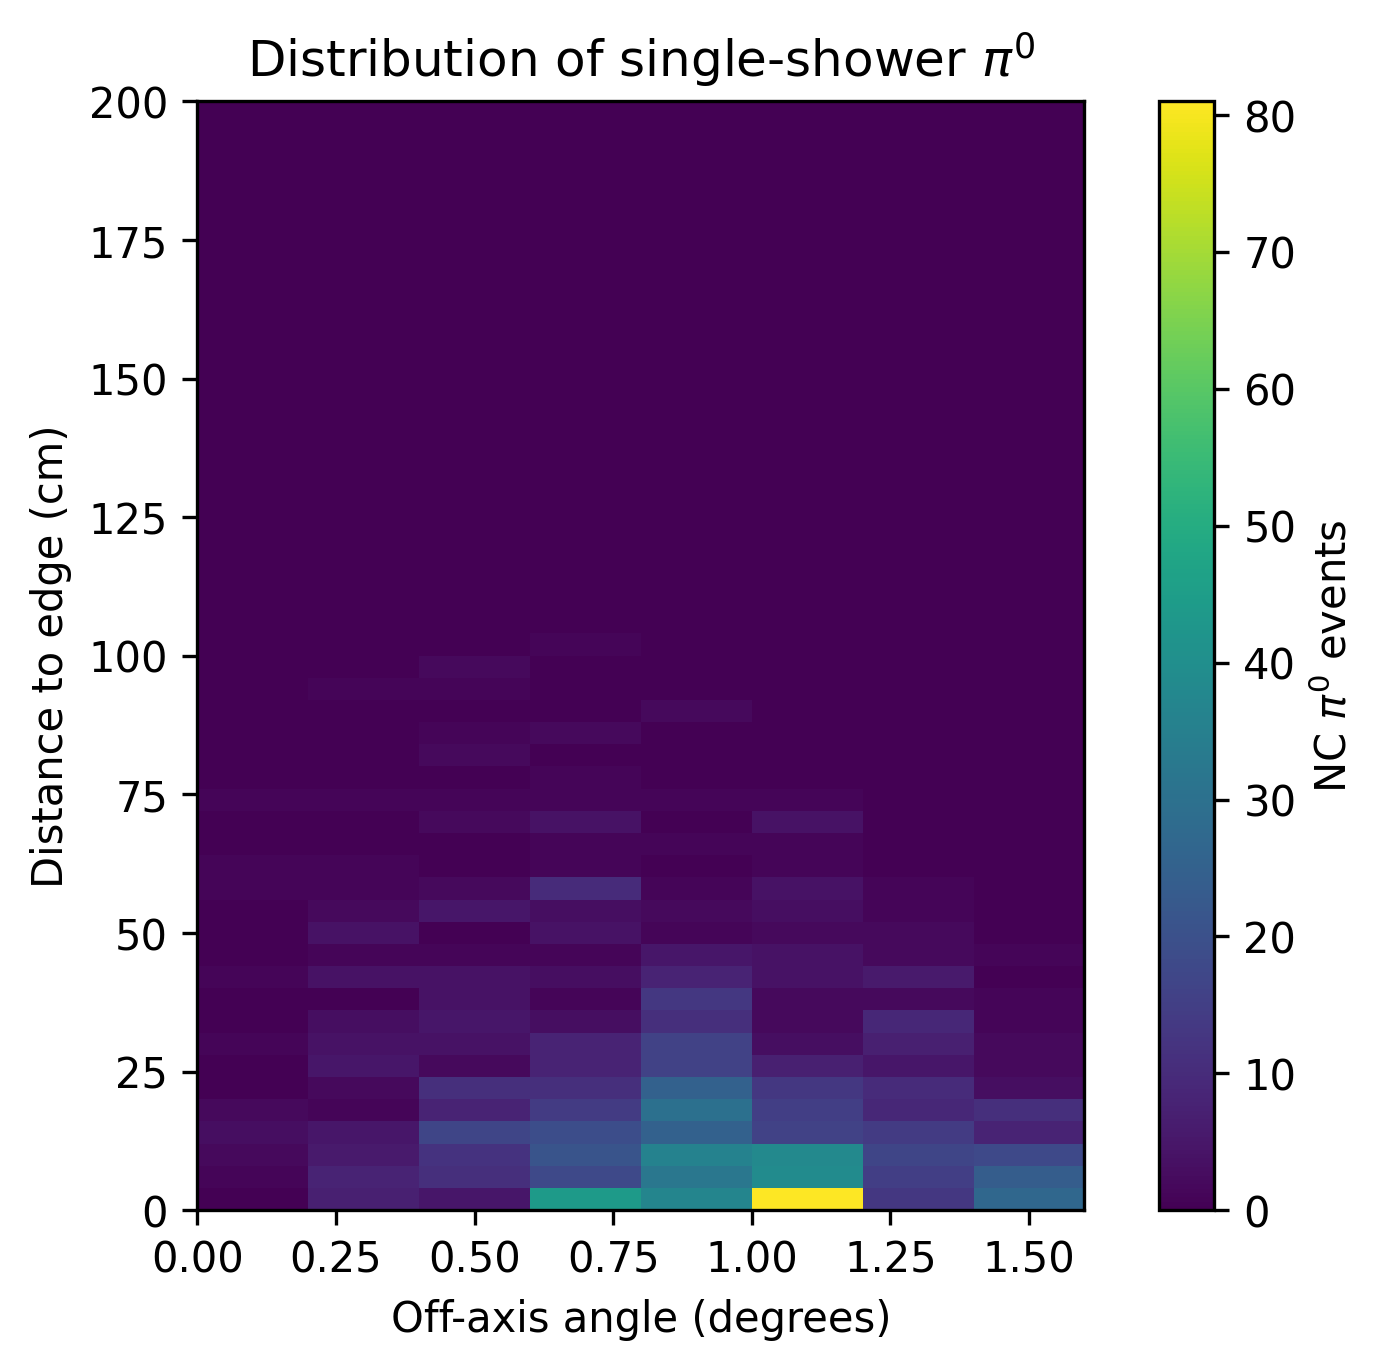

In [55]:
distAngHeatmap = np.zeros((len(distBins[:-1]), len(nbinsTPC[:-1])))
for idx, row in df[df['is_NC'] & df['single_shower']].iterrows():
    run = False
    if 2212 in row['mc_pdg']:
        pDex = np.where(row['mc_pdg'] == 2212)[0][0]
        if row['mc_energy'][pDex] > 0.035:
            run = row['in_TPC_g4'][row['shower_pi0_dex'][0]]
    if run:
        for k in range(len(row['pi0_angle_exact'])):
            angDex = np.digitize(row['pi0_angle_exact'][k], nbinsTPC[:-1]) - 1
            distDex = np.digitize(row['dist_to_edge_g4'][row['shower_pi0_dex'][0]], distBins[:-1]) - 1
            distAngHeatmap[distDex, angDex] += 1

plt.figure(dpi=300)
plt.imshow(distAngHeatmap, cmap='viridis', extent=[nbinsTPC[0], nbinsTPC[-1], distBins[-1], distBins[0]], aspect=.01)
plt.xlabel("Off-axis angle (degrees)")
plt.ylabel("Distance to edge (cm)")
plt.colorbar(label="NC $\pi^0$ events")
plt.gca().invert_yaxis()
plt.title("Distribution of single-shower $\pi^0$")
plt.show()

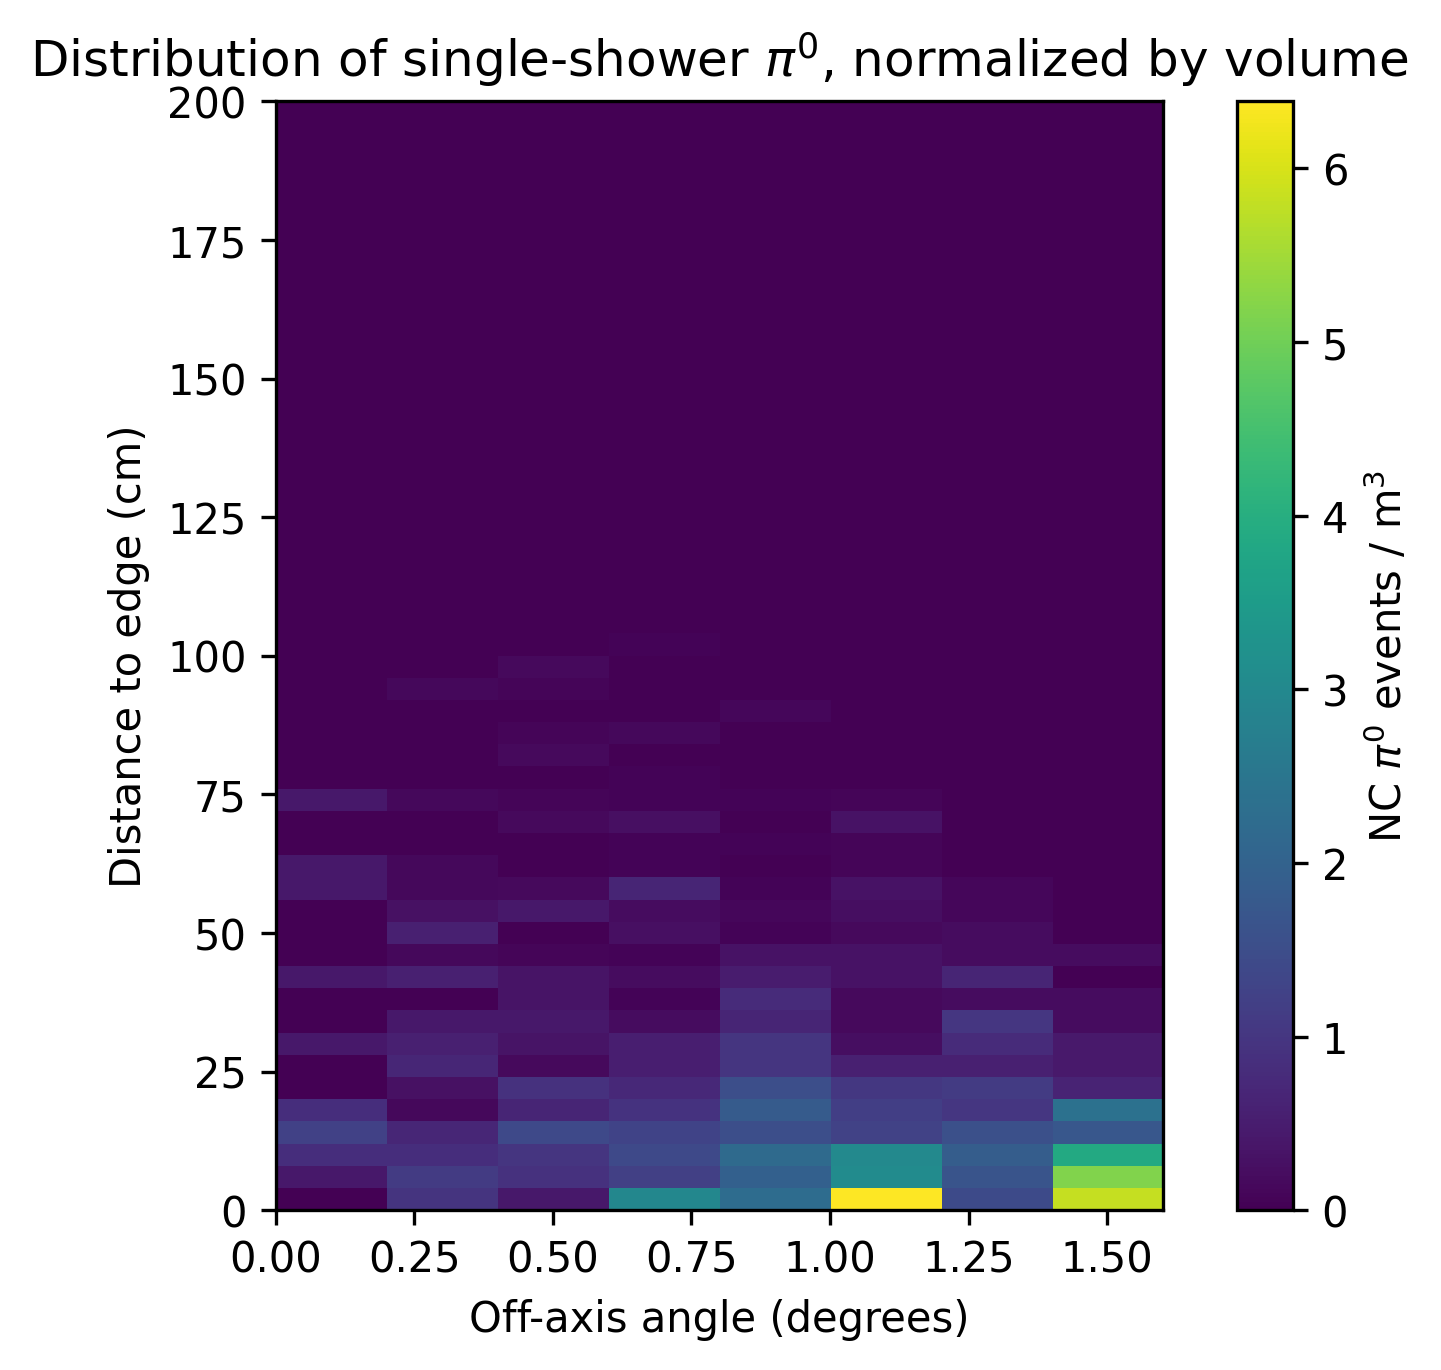

In [59]:
distAngHeatmap = np.zeros((len(distBins[:-1]), len(nbinsTPC[:-1])))
for idx, row in df[df['is_NC'] & df['single_shower']].iterrows():
    run = False
    if 2212 in row['mc_pdg']:
        pDex = np.where(row['mc_pdg'] == 2212)[0][0]
        if row['mc_energy'][pDex] > 0.035:
            run = row['in_TPC_g4'][row['shower_pi0_dex'][0]]
    if run:
        for k in range(len(row['pi0_angle_exact'])):
            angDex = np.digitize(row['pi0_angle_exact'][k], nbinsTPC[:-1]) - 1
            distDex = np.digitize(row['dist_to_edge_g4'][row['shower_pi0_dex'][0]], distBins[:-1]) - 1
            distAngHeatmap[distDex, angDex] += 1/norm_vols[angDex]

plt.figure(dpi=300)
plt.imshow(distAngHeatmap, cmap='viridis', extent=[nbinsTPC[0], nbinsTPC[-1], distBins[-1], distBins[0]], aspect=.01)
plt.xlabel("Off-axis angle (degrees)")
plt.ylabel("Distance to edge (cm)")
plt.colorbar(label="NC $\pi^0$ events / m$^3$")
plt.gca().invert_yaxis()
plt.title("Distribution of single-shower $\pi^0$, normalized by volume")
plt.show()

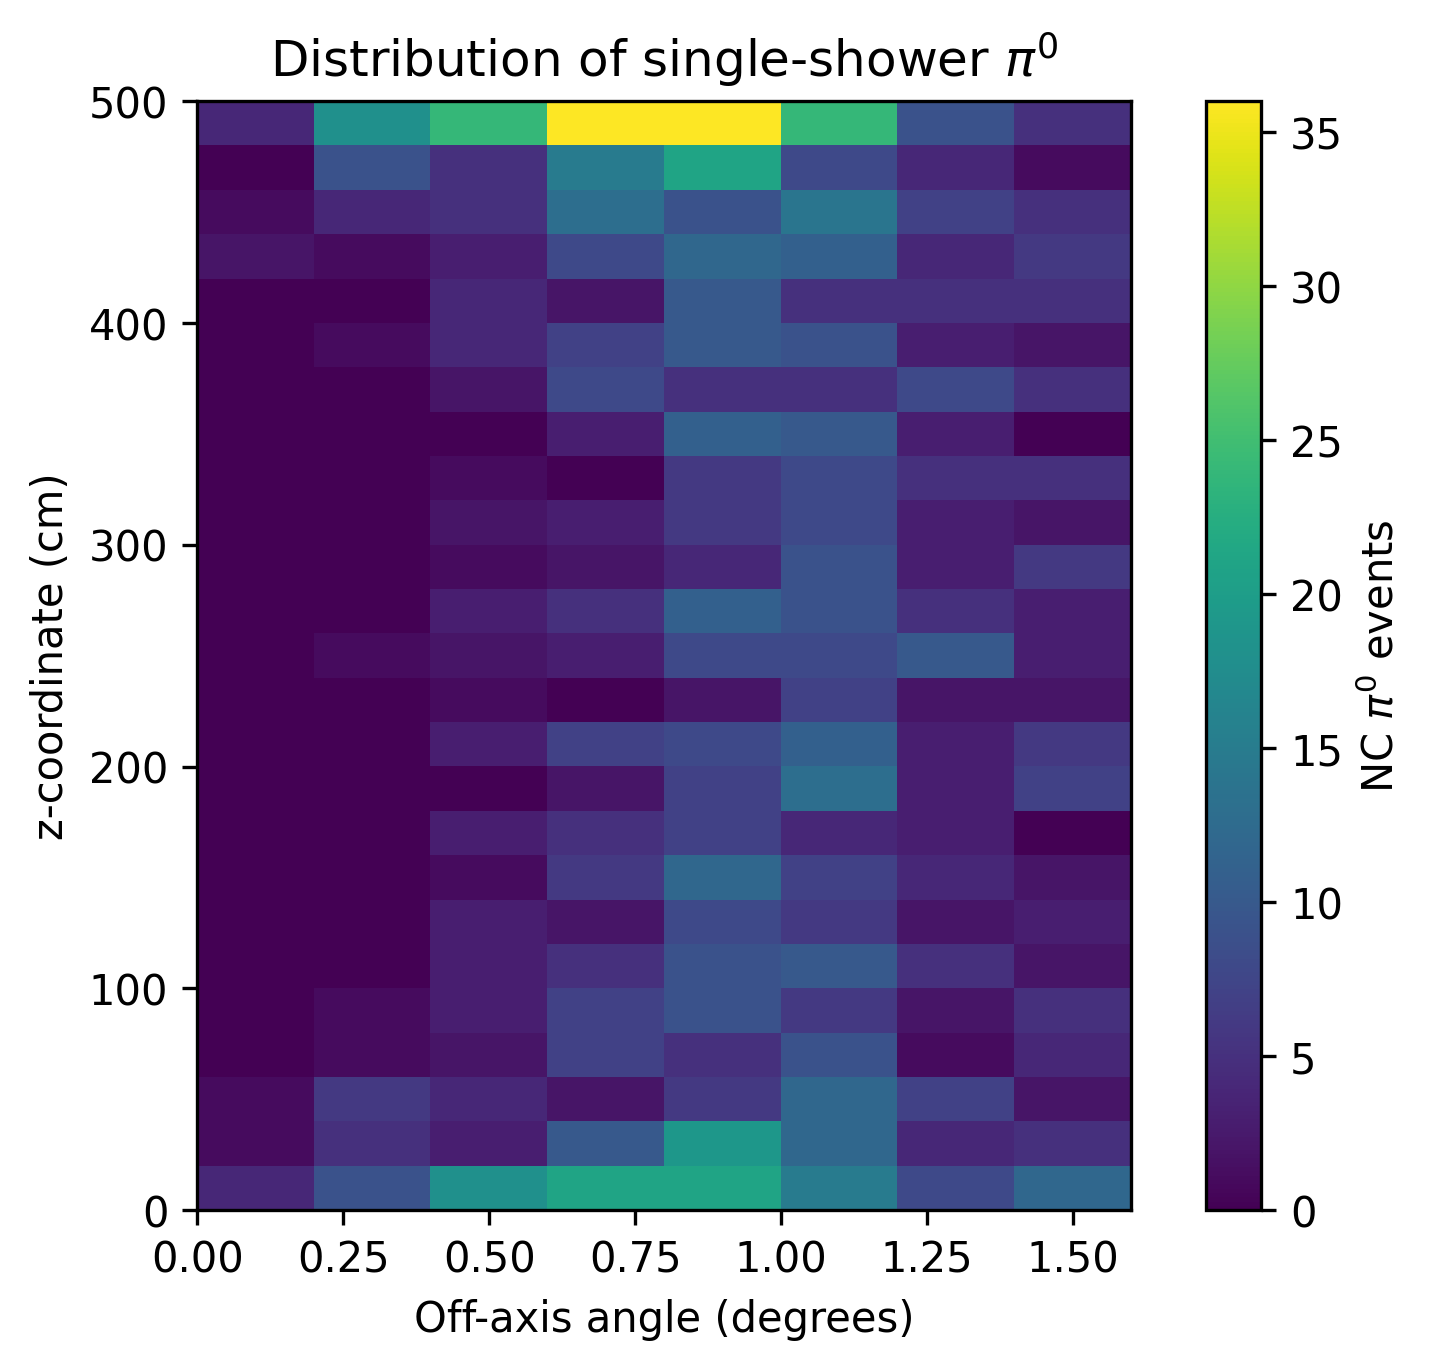

In [61]:
zAngHeatmap = np.zeros((len(zBins[:-1]), len(nbinsTPC[:-1])))
for idx, row in df[df['is_NC'] & df['single_shower']].iterrows():
    run = False
    if 2212 in row['mc_pdg']:
        pDex = np.where(row['mc_pdg'] == 2212)[0][0]
        if row['mc_energy'][pDex] > 0.035:
            run = row['in_TPC_g4'][row['shower_pi0_dex'][0]]
    if run:
        for k in range(len(row['pi0_angle_exact'])):
            angDex = np.digitize(row['pi0_angle_exact'][k], nbinsTPC[:-1]) - 1
            zDex = np.digitize(row['StartPointz'][row['shower_pi0_dex'][0]], zBins[:-1]) - 1
            zAngHeatmap[zDex, angDex] += 1

plt.figure(dpi=300)
plt.imshow(zAngHeatmap, cmap='viridis', extent=[nbinsTPC[0], nbinsTPC[-1], zBins[-1], zBins[0]], aspect=.0038)
plt.xlabel("Off-axis angle (degrees)")
plt.ylabel("z-coordinate (cm)")
plt.colorbar(label="NC $\pi^0$ events")
plt.gca().invert_yaxis()
plt.title("Distribution of single-shower $\pi^0$")
plt.show()

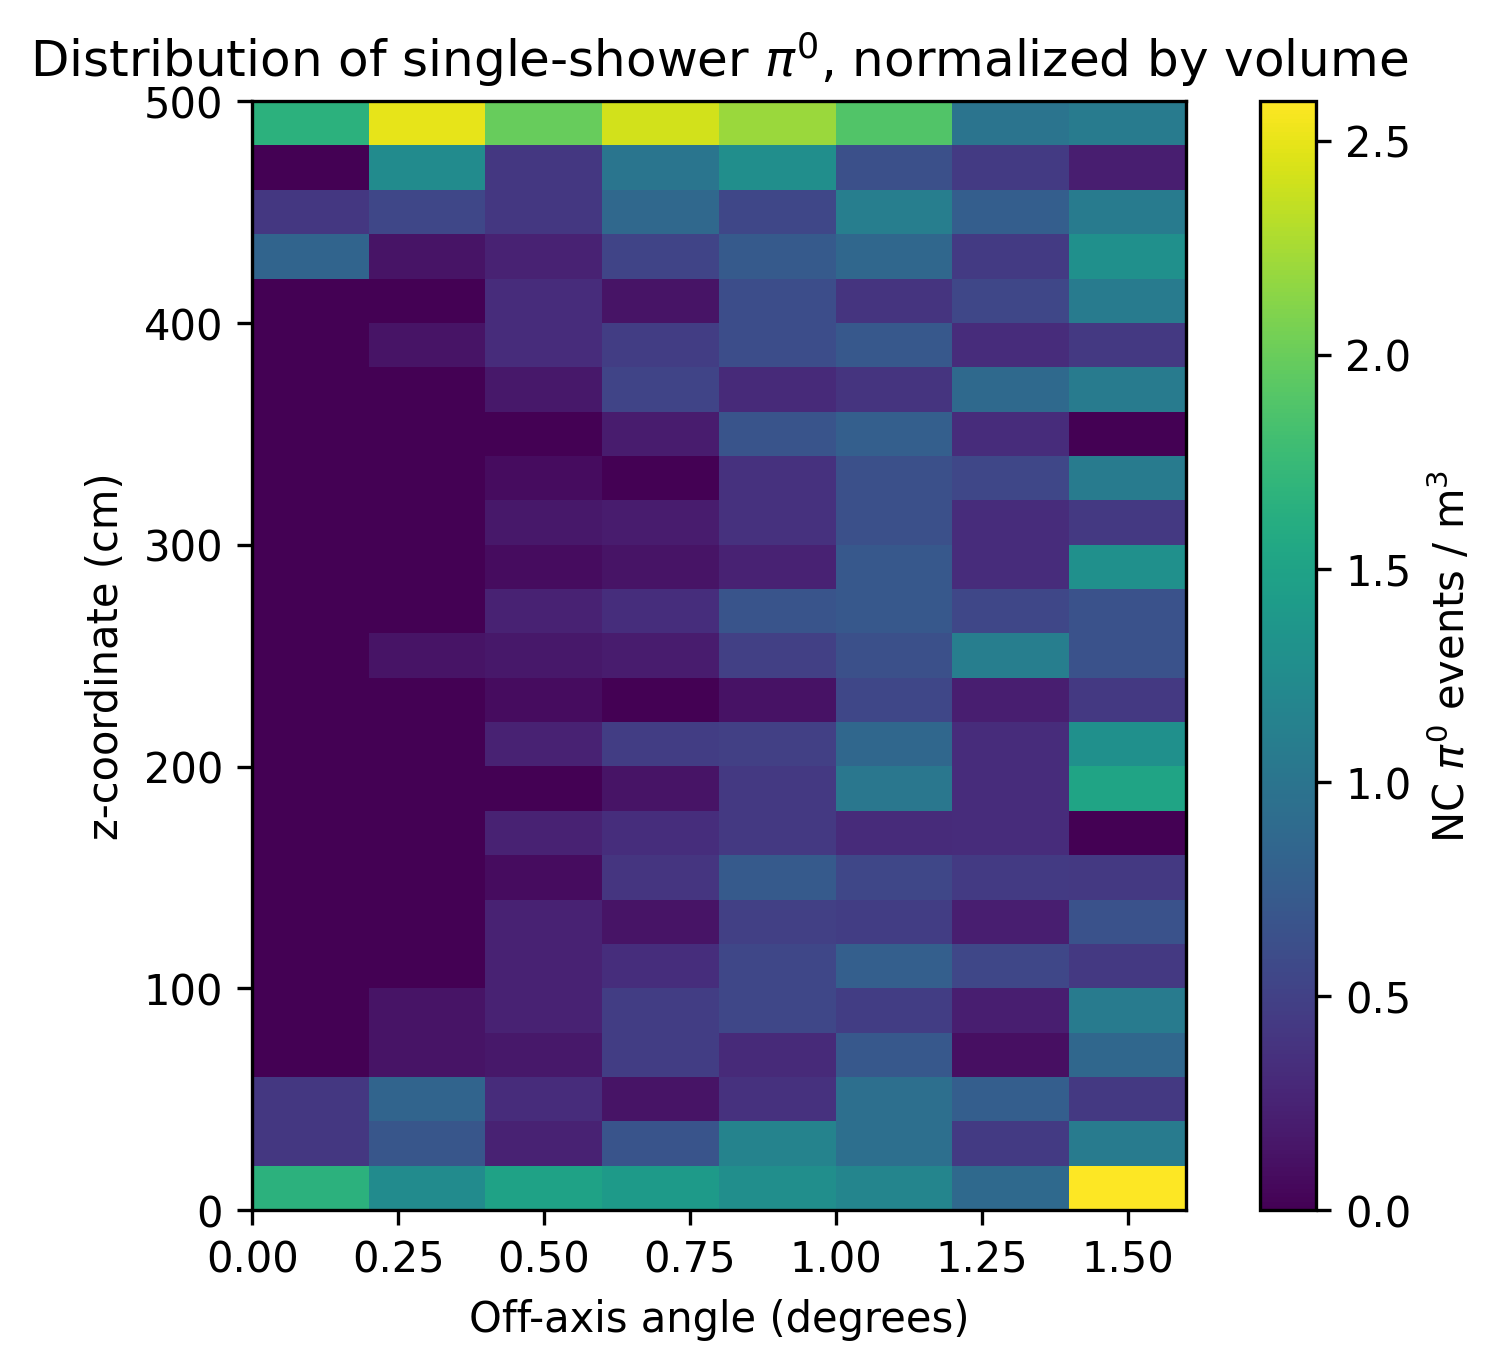

In [62]:
zAngHeatmap = np.zeros((len(zBins[:-1]), len(nbinsTPC[:-1])))
for idx, row in df[df['is_NC'] & df['single_shower']].iterrows():
    run = False
    if 2212 in row['mc_pdg']:
        pDex = np.where(row['mc_pdg'] == 2212)[0][0]
        if row['mc_energy'][pDex] > 0.035:
            run = row['in_TPC_g4'][row['shower_pi0_dex'][0]]
    if run:
        for k in range(len(row['pi0_angle_exact'])):
            angDex = np.digitize(row['pi0_angle_exact'][k], nbinsTPC[:-1]) - 1
            zDex = np.digitize(row['StartPointz'][row['shower_pi0_dex'][0]], zBins[:-1]) - 1
            zAngHeatmap[zDex, angDex] += 1/norm_vols[angDex]

plt.figure(dpi=300)
plt.imshow(zAngHeatmap, cmap='viridis', extent=[nbinsTPC[0], nbinsTPC[-1], zBins[-1], zBins[0]], aspect=.0038)
plt.xlabel("Off-axis angle (degrees)")
plt.ylabel("z-coordinate (cm)")
plt.colorbar(label="NC $\pi^0$ events / m$^3$")
plt.gca().invert_yaxis()
plt.title("Distribution of single-shower $\pi^0$, normalized by volume")
plt.show()

## Set A: 2 showers (interaction vertex)

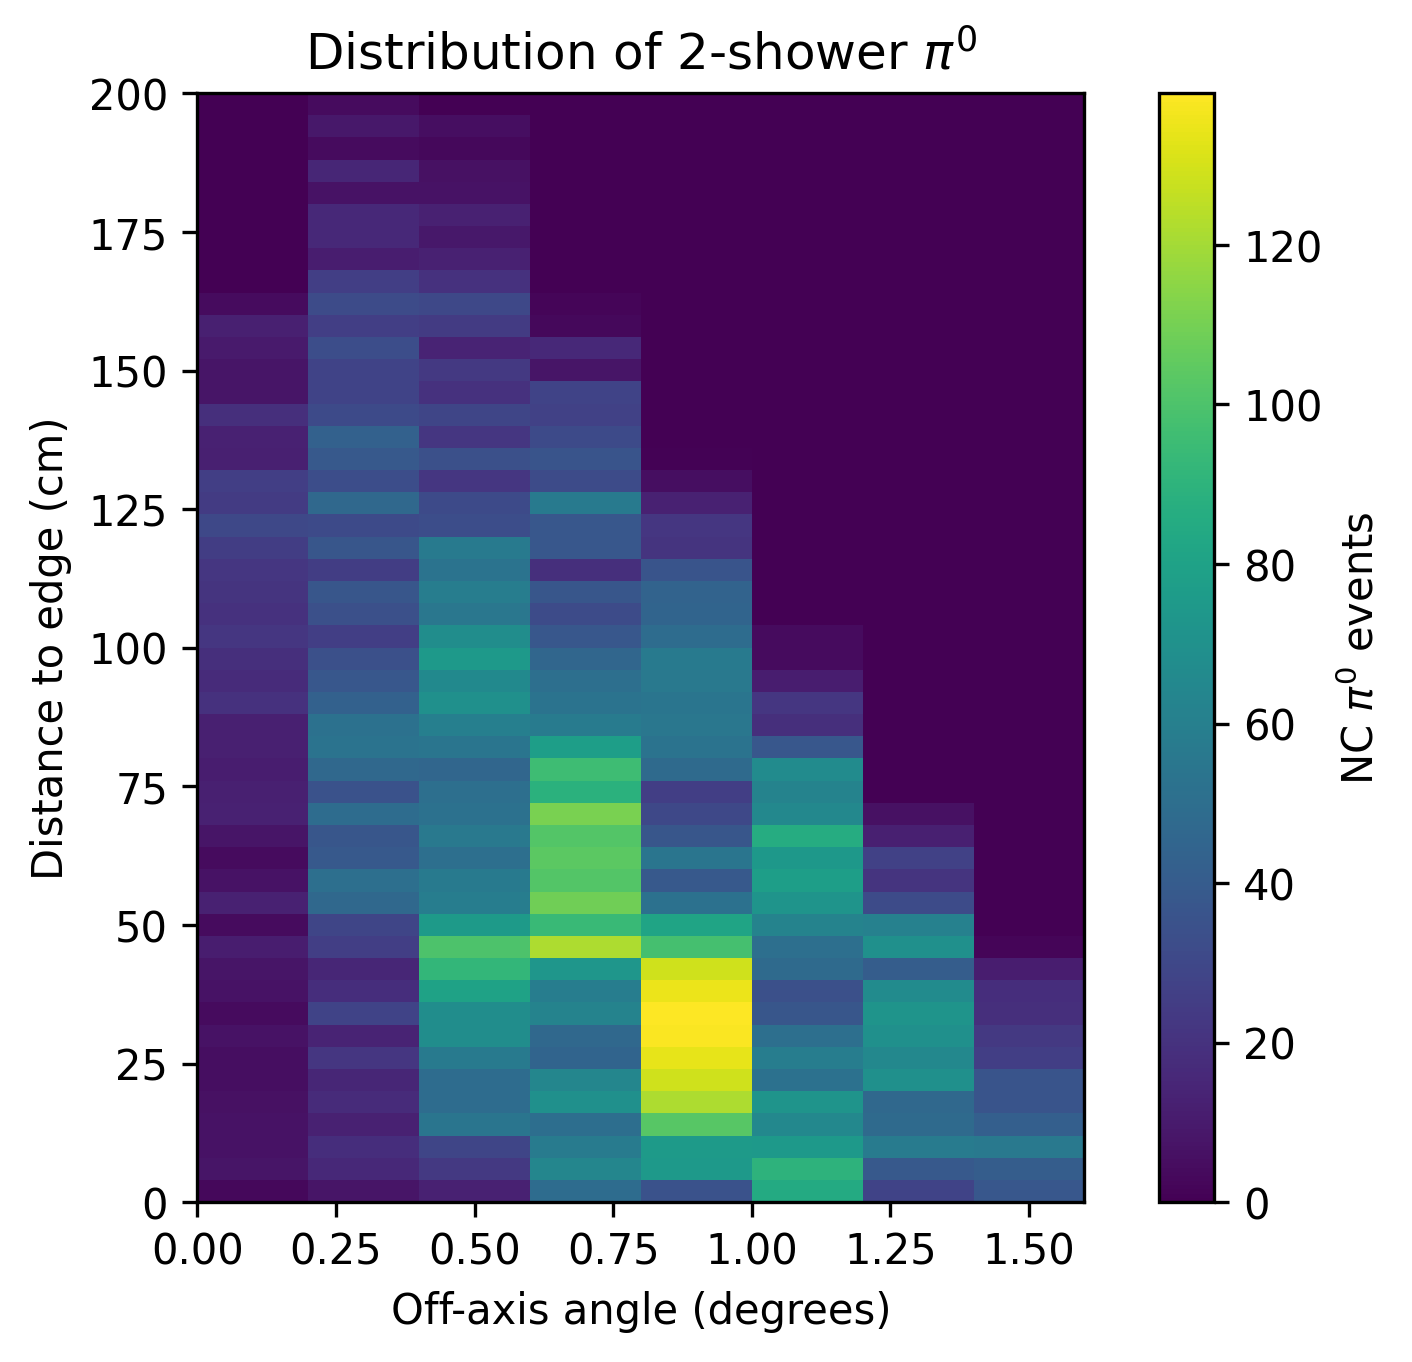

In [64]:
distAngHeatmap = np.zeros((len(distBins[:-1]), len(nbinsTPC[:-1])))
for idx, row in df[df['is_NC']].iterrows():
    run = False
    if row['N_showers'] == 2:
        if len(row['shower_pi0_dex']) == 1:
            run = row['in_TPC_g4'][row['shower_pi0_dex'][0]]
    if run:
        for k in range(len(row['pi0_angle_exact'])):
            angDex = np.digitize(row['pi0_angle_exact'][k], nbinsTPC[:-1]) - 1
            distDex = np.digitize(row['dist_to_edge_g4'][row['shower_pi0_dex'][0]], distBins[:-1]) - 1
            distAngHeatmap[distDex, angDex] += 1

plt.figure(dpi=300)
plt.imshow(distAngHeatmap, cmap='viridis', extent=[nbinsTPC[0], nbinsTPC[-1], distBins[-1], distBins[0]], aspect=.01)
plt.xlabel("Off-axis angle (degrees)")
plt.ylabel("Distance to edge (cm)")
plt.colorbar(label="NC $\pi^0$ events")
plt.gca().invert_yaxis()
plt.title("Distribution of 2-shower $\pi^0$")
plt.show()

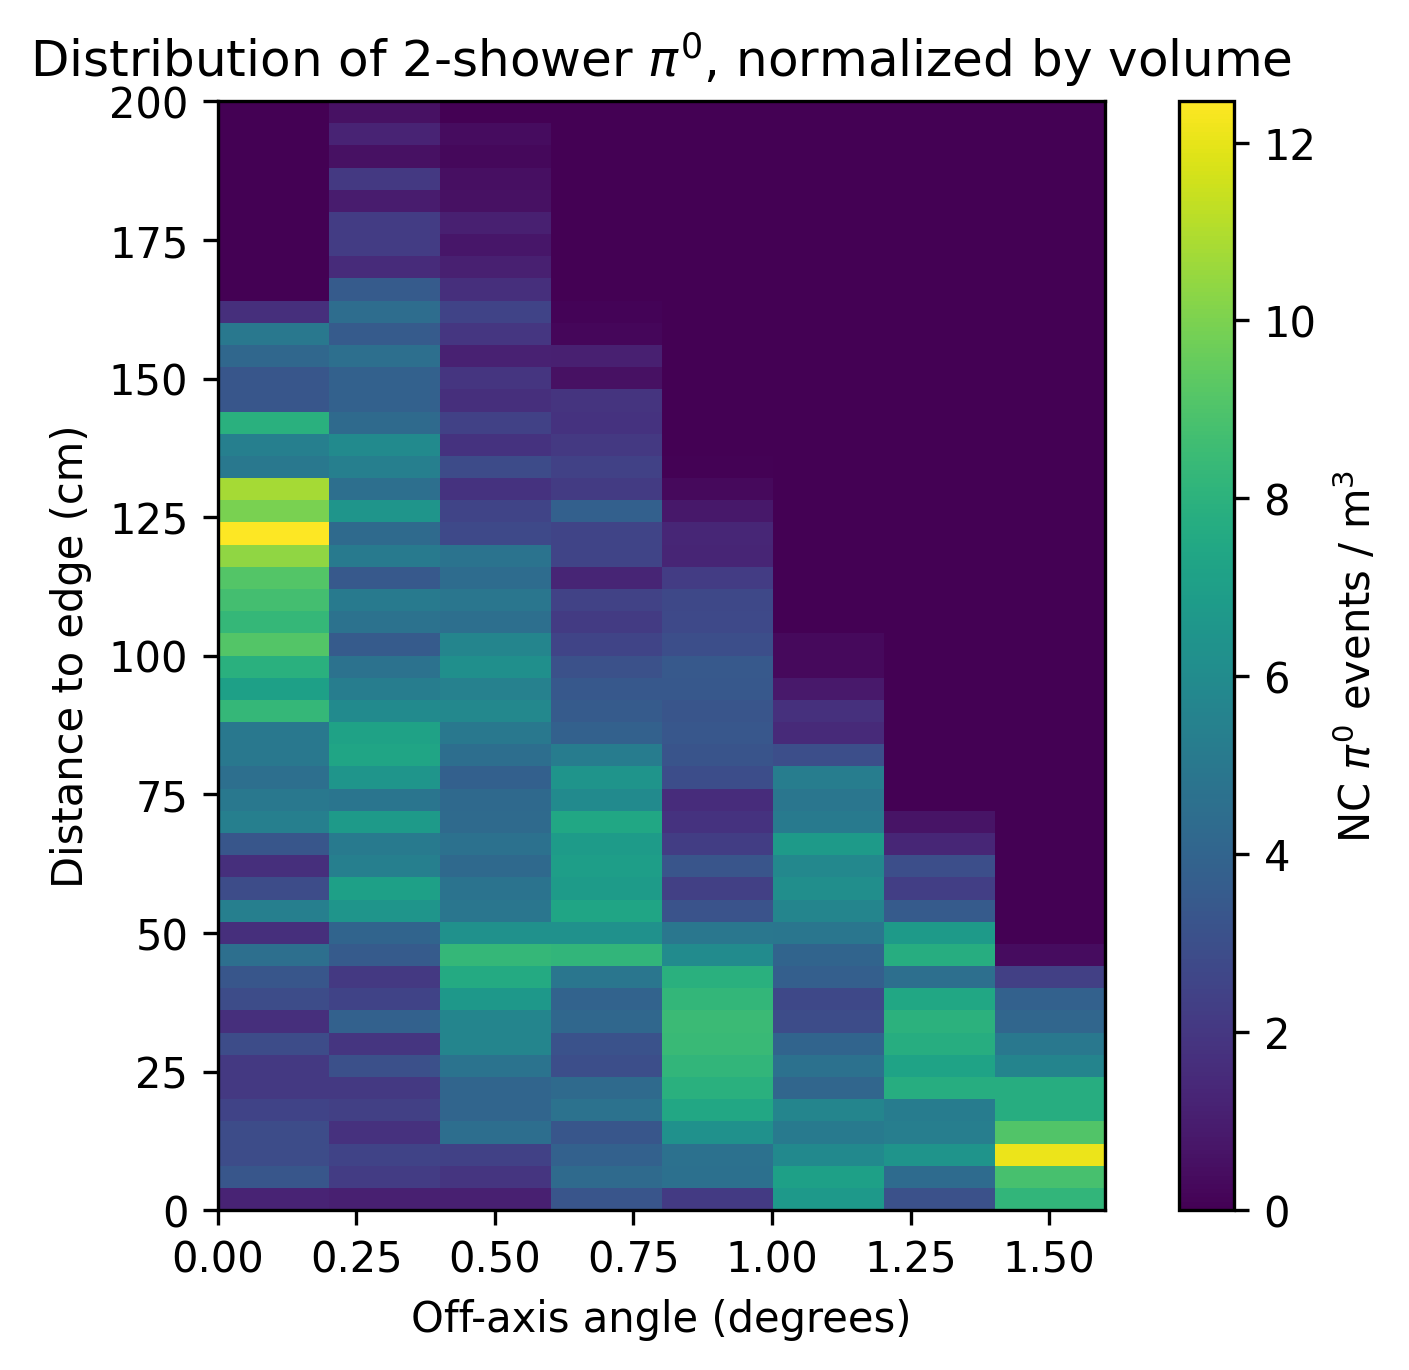

In [65]:
distAngHeatmap = np.zeros((len(distBins[:-1]), len(nbinsTPC[:-1])))
for idx, row in df[df['is_NC']].iterrows():
    run = False
    if row['N_showers'] == 2:
        if len(row['shower_pi0_dex']) == 1:
            run = row['in_TPC_g4'][row['shower_pi0_dex'][0]]
    if run:
        for k in range(len(row['pi0_angle_exact'])):
            angDex = np.digitize(row['pi0_angle_exact'][k], nbinsTPC[:-1]) - 1
            distDex = np.digitize(row['dist_to_edge_g4'][row['shower_pi0_dex'][0]], distBins[:-1]) - 1
            distAngHeatmap[distDex, angDex] += 1/norm_vols[angDex]

plt.figure(dpi=300)
plt.imshow(distAngHeatmap, cmap='viridis', extent=[nbinsTPC[0], nbinsTPC[-1], distBins[-1], distBins[0]], aspect=.01)
plt.xlabel("Off-axis angle (degrees)")
plt.ylabel("Distance to edge (cm)")
plt.colorbar(label="NC $\pi^0$ events / m$^3$")
plt.gca().invert_yaxis()
plt.title("Distribution of 2-shower $\pi^0$, normalized by volume")
plt.show()

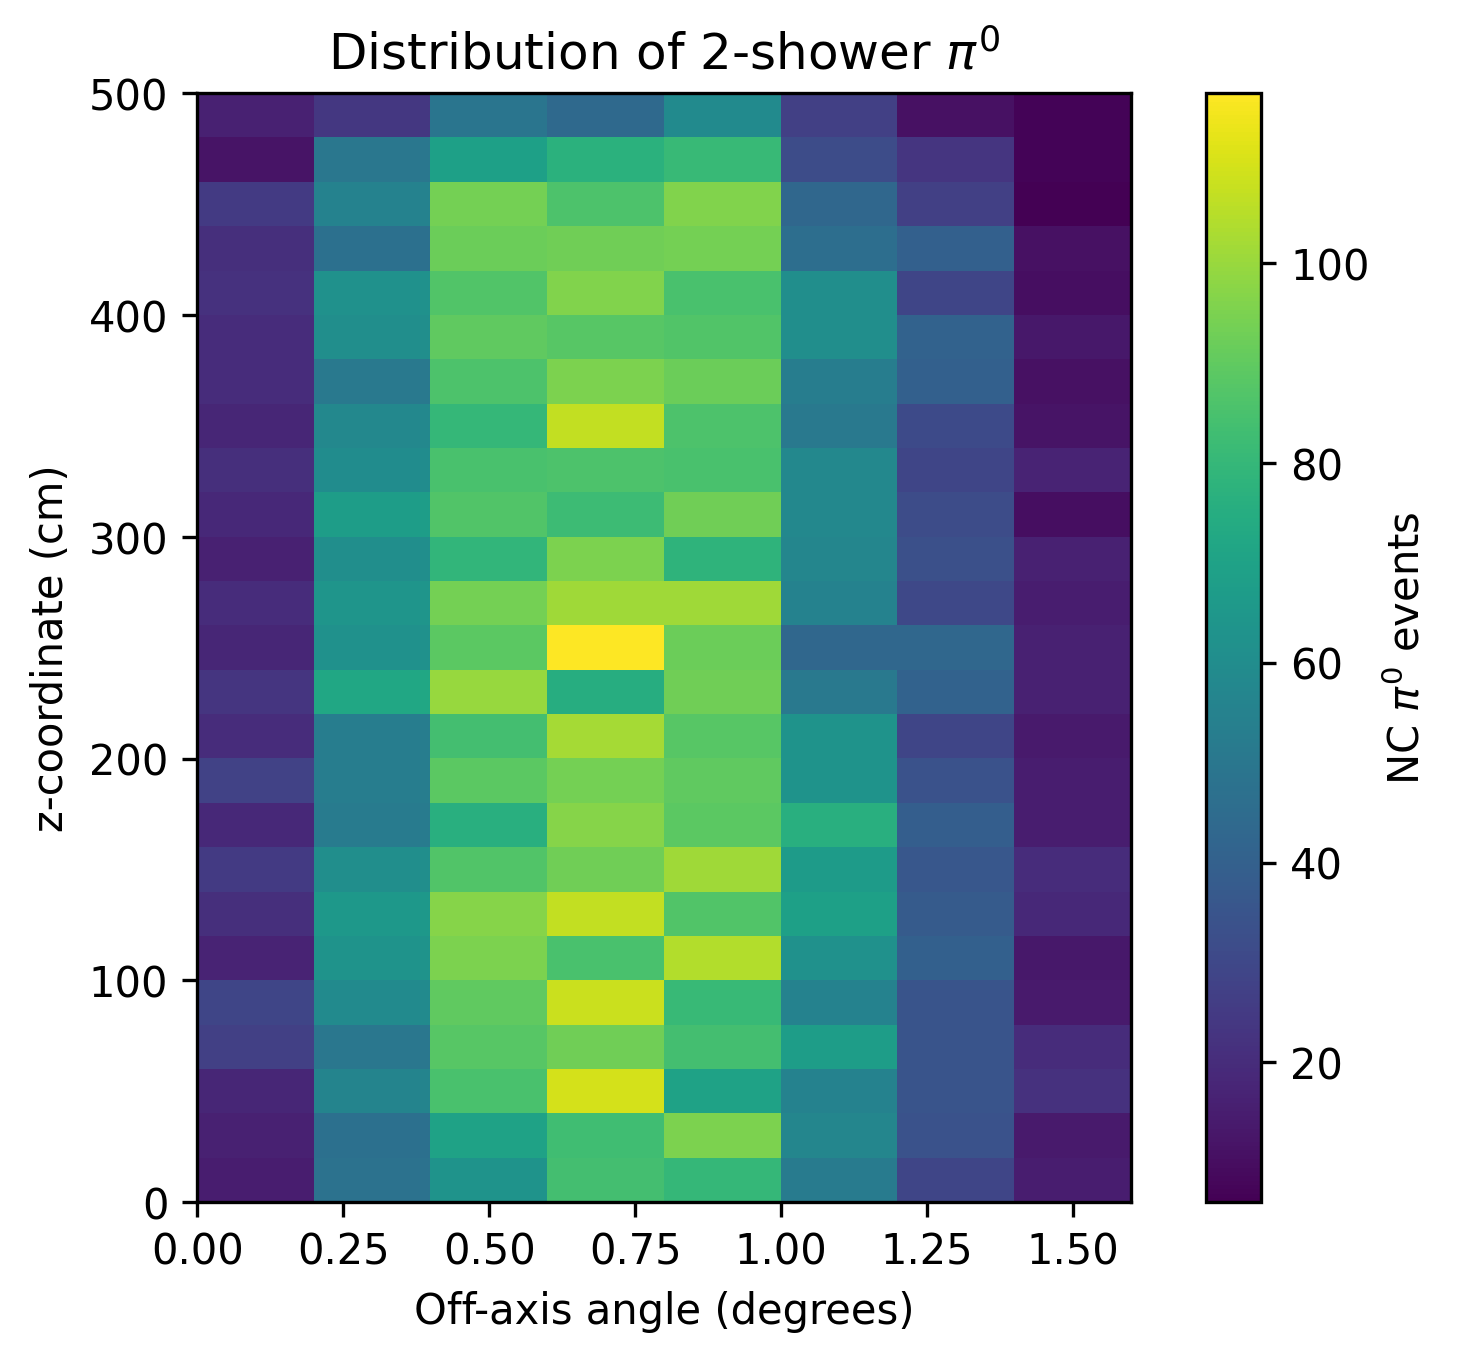

In [66]:
zAngHeatmap = np.zeros((len(zBins[:-1]), len(nbinsTPC[:-1])))
for idx, row in df[df['is_NC']].iterrows():
    run = False
    if row['N_showers'] == 2:
        if len(row['shower_pi0_dex']) == 1:
            run = row['in_TPC_g4'][row['shower_pi0_dex'][0]]
    if run:
        for k in range(len(row['pi0_angle_exact'])):
            angDex = np.digitize(row['pi0_angle_exact'][k], nbinsTPC[:-1]) - 1
            zDex = np.digitize(row['StartPointz'][row['shower_pi0_dex'][0]], zBins[:-1]) - 1
            zAngHeatmap[zDex, angDex] += 1

plt.figure(dpi=300)
plt.imshow(zAngHeatmap, cmap='viridis', extent=[nbinsTPC[0], nbinsTPC[-1], zBins[-1], zBins[0]], aspect=.0038)
plt.xlabel("Off-axis angle (degrees)")
plt.ylabel("z-coordinate (cm)")
plt.colorbar(label="NC $\pi^0$ events")
plt.gca().invert_yaxis()
plt.title("Distribution of 2-shower $\pi^0$")
plt.show()

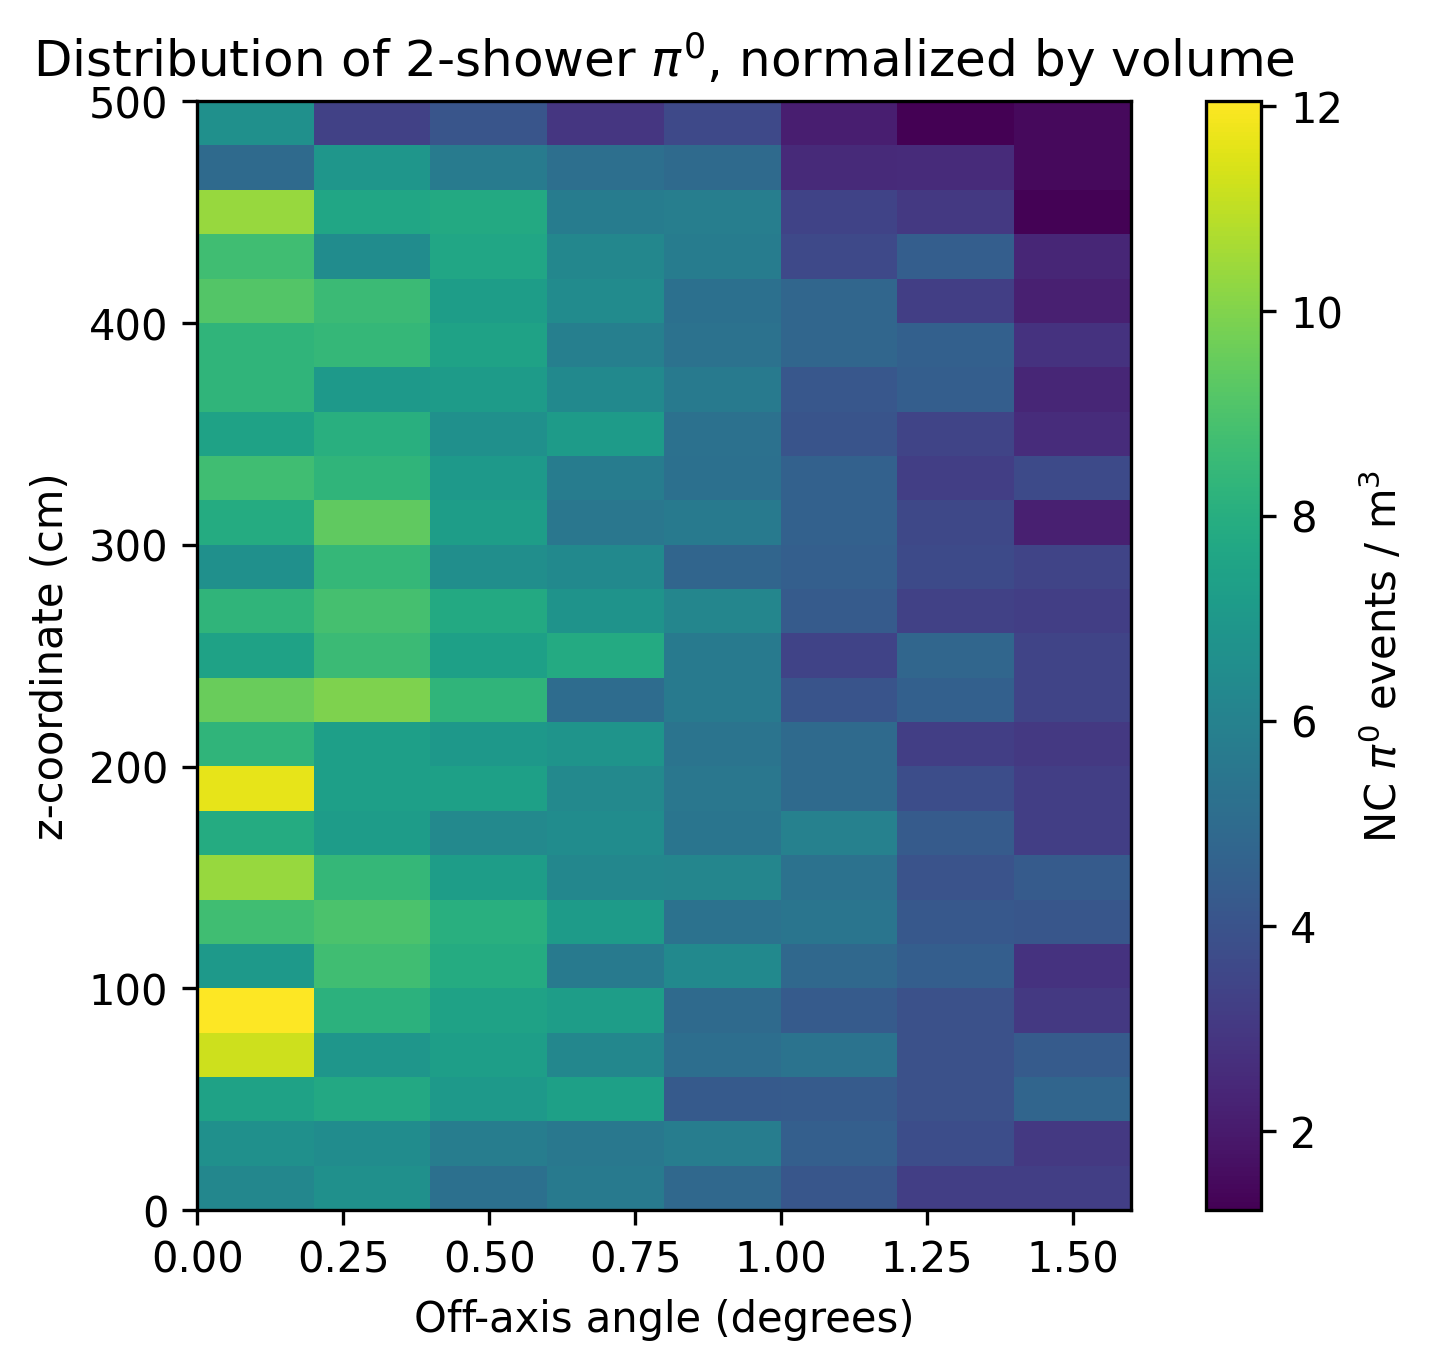

In [67]:
zAngHeatmap = np.zeros((len(zBins[:-1]), len(nbinsTPC[:-1])))
for idx, row in df[df['is_NC']].iterrows():
    run = False
    if row['N_showers'] == 2:
        if len(row['shower_pi0_dex']) == 1:
            run = row['in_TPC_g4'][row['shower_pi0_dex'][0]]
    if run:
        for k in range(len(row['pi0_angle_exact'])):
            angDex = np.digitize(row['pi0_angle_exact'][k], nbinsTPC[:-1]) - 1
            zDex = np.digitize(row['StartPointz'][row['shower_pi0_dex'][0]], zBins[:-1]) - 1
            zAngHeatmap[zDex, angDex] += 1/norm_vols[angDex]

plt.figure(dpi=300)
plt.imshow(zAngHeatmap, cmap='viridis', extent=[nbinsTPC[0], nbinsTPC[-1], zBins[-1], zBins[0]], aspect=.0038)
plt.xlabel("Off-axis angle (degrees)")
plt.ylabel("z-coordinate (cm)")
plt.colorbar(label="NC $\pi^0$ events / m$^3$")
plt.gca().invert_yaxis()
plt.title("Distribution of 2-shower $\pi^0$, normalized by volume")
plt.show()

## Set D: 2-showers, 1 failed (surviving shower head)